# ✅ Phase 1: Imports and Environment Setup
 This section includes all necessary imports for file handling, Hadoop streaming, Spark integration, machine learning, visualization, and MongoDB operations.

In [ ]:
# 📦 Core Python Modules
import os
import sys
import csv
import subprocess
import logging
import shutil
import glob
import builtins

# 📊 Visualization
import matplotlib.pyplot as plt

# 🔥 Spark Setup
import findspark
findspark.init()
from pyspark.sql import SparkSession
from pyspark.sql import functions as F
from pyspark.sql.functions import col, when, sum as Fsum, count, round, mean, stddev, lower, regexp_replace
from pyspark.sql.types import StringType, IntegerType
from pyspark.ml import Pipeline
from pyspark.ml.feature import StringIndexer, VectorAssembler

# 🧮 Data Manipulation
import pandas as pd
import numpy as np

# 🤖 Machine Learning (Scikit-learn)
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.model_selection import train_test_split, GridSearchCV, cross_val_score
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import (
    accuracy_score, confusion_matrix, precision_score,
    recall_score, f1_score, classification_report
)
from sklearn.utils import resample

# 🗄️ MongoDB & JSON
from pymongo import MongoClient
import json

# 🧾 Logging Configuration
logging.basicConfig(
    format='%(asctime)s %(levelname)s: %(message)s',
    level=logging.INFO
)


# ✅ Phase 2: Upload Raw CSVs to HDFS
Place the original hotel and country-city files into HDFS for MapReduce and Spark

In [5]:
# 2.0 Define base HDFS directory for this project
hdfs_base = "/user/behnaz"
hdfs_input = f"{hdfs_base}/input"

# 2.1 Remove the entire project directory (if exists) to start fresh
#     This deletes both input and any other subdirectories under /user/behnaz
subprocess.run(["hdfs", "dfs", "-rm", "-r", "-f", hdfs_base], check=False)
logging.info(f"Deleted HDFS base directory {hdfs_base}")

# 2.2 Recreate base and input directories
subprocess.run(["hdfs", "dfs", "-mkdir", "-p", hdfs_input], check=True)
logging.info(f"Recreated HDFS directories {hdfs_base} and {hdfs_input}")

# 2.3 Upload raw CSV files into the fresh input directory
for fname in ["hotel_bookings.csv", "country_city.csv"]:
    local_path = fname
    hdfs_path = f"{hdfs_input}/{fname}"
    subprocess.run(
        ["hdfs", "dfs", "-put", "-f", local_path, hdfs_path],
        check=True
    )
    logging.info(f"Uploaded {local_path} to {hdfs_path}")

# 2.4 Verify that input directory contains exactly the two files
listing = subprocess.run(
    ["hdfs", "dfs", "-ls", hdfs_input],
    stdout=subprocess.PIPE, text=True
)
print("HDFS input directory listing after reset and upload:")
print(listing.stdout)

# 2.5 Count rows and columns for each CSV on HDFS
for fname in ["hotel_bookings.csv", "country_city.csv"]:
    hdfs_file = f"{hdfs_input}/{fname}"
    # Read entire file
    cat = subprocess.run(
        ["hdfs", "dfs", "-cat", hdfs_file],
        stdout=subprocess.PIPE, text=True
    ).stdout.strip().splitlines()
    # First line is header
    header = cat[0].split(",")
    num_rows = max(len(cat) - 1, 0)
    num_cols = len(header)
    print(f"{fname} → rows: {num_rows}, cols: {num_cols}")

Deleted /user/behnaz


2025-06-14 09:24:53,221 INFO: Deleted HDFS base directory /user/behnaz
2025-06-14 09:24:54,434 INFO: Recreated HDFS directories /user/behnaz and /user/behnaz/input
2025-06-14 09:24:56,588 INFO: Uploaded hotel_bookings.csv to /user/behnaz/input/hotel_bookings.csv
2025-06-14 09:24:58,129 INFO: Uploaded country_city.csv to /user/behnaz/input/country_city.csv


HDFS input directory listing after reset and upload:
Found 2 items
-rw-r--r--   1 ubuntu supergroup       3529 2025-06-14 09:24 /user/behnaz/input/country_city.csv
-rw-r--r--   1 ubuntu supergroup   16855599 2025-06-14 09:24 /user/behnaz/input/hotel_bookings.csv

hotel_bookings.csv → rows: 119390, cols: 32
country_city.csv → rows: 251, cols: 2


# ✅ Phase 3: Local MapReduce Join (HDFS Input)


In [6]:
def mapreduce_join_and_upload():
    # 3.1 Write mapper.py
    with open('mapper.py', 'w') as mp:
        mp.write(r"""
import sys, csv
reader = csv.reader(sys.stdin)
for row in reader:
    if len(row) > 13:
        country = row[13].strip() or 'Unknown'
        print(f"{country}\tA\t{','.join(row)}")
    elif len(row) >= 2:
        country = row[0].strip() or 'Unknown'
        city    = row[1].strip() or 'Unknown'
        print(f"{country}\tB\t{city}")
""")

    # 3.2 Write reducer.py
    with open('reducer.py', 'w') as rd:
        rd.write(r"""
import sys
current = None
rows = []
city = None
for line in sys.stdin:
    country, tag, data = line.strip().split('\t', 2)
    if current and country != current:
        for r in rows:
            print(r + ',' + (city or 'Unknown'))
        rows, city = [], None
    current = country
    if tag == 'A':
        rows.append(data)
    elif tag == 'B' and not city:
        city = data
if current:
    for r in rows:
        print(r + ',' + (city or 'Unknown'))
""")

    # 3.3 Execute local MapReduce steps using HDFS input
    # Read hotel_bookings.csv from HDFS, skip header, pipe to mapper
    os.system(
        "hdfs dfs -cat /user/behnaz/input/hotel_bookings.csv | "
        "tail -n +2 | python mapper.py > map_hotel.txt"
    )
    # Read country_city.csv from HDFS, skip header, pipe to mapper
    os.system(
        "hdfs dfs -cat /user/behnaz/input/country_city.csv | "
        "tail -n +2 | python mapper.py > map_lookup.txt"
    )
    # Sort and reduce locally
    os.system("cat map_hotel.txt map_lookup.txt | sort > mapper_sorted.txt")
    os.system("python reducer.py < mapper_sorted.txt > joined_local.csv")

    # 3.4 Upload the joined CSV back to HDFS
    hdfs_output = "/user/behnaz/output/joined_hotel_city"
    subprocess.run(["hdfs","dfs","-rm","-r","-f", hdfs_output], check=False)
    subprocess.run(["hdfs","dfs","-mkdir","-p", hdfs_output], check=True)
    subprocess.run([
        "hdfs","dfs","-put","-f","joined_local.csv", hdfs_output + "/"
    ], check=True)
    logging.info(f"Joined file uploaded to HDFS at {hdfs_output}")

    # 3.5 Final check: read back and print dimensions
    joined_lines = subprocess.run(
        ["hdfs","dfs","-cat", f"{hdfs_output}/joined_local.csv"],
        stdout=subprocess.PIPE, text=True
    ).stdout.strip().splitlines()
    rows = len(joined_lines)
    cols = len(joined_lines[0].split(',')) if rows > 0 else 0
    print(f"Joined data dimensions → rows: {rows}, cols: {cols}")

# Trigger the MapReduce join
mapreduce_join_and_upload()

2025-06-14 09:25:11,877 INFO: Joined file uploaded to HDFS at /user/behnaz/output/joined_hotel_city


Joined data dimensions → rows: 119390, cols: 33


# ✅ Phase 4: Load & Explore Joined Data From HDFS


In [7]:
def load_and_explore_joined_data(
    hdfs_dir="hdfs://localhost:9000/user/behnaz/output/joined_hotel_city"
):
    """
    1. Load joined CSV files from HDFS into a Spark DataFrame with correct schema.
    2. Normalize all forms of missing/illogical values to null.
    3. Perform exploratory analysis and hypothesis testing.
    """
    # 4.1 Initialize SparkSession
    spark = SparkSession.builder \
        .appName("HotelBookingAnalysis_Phase4") \
        .config("spark.sql.shuffle.partitions", "50") \
        .getOrCreate()

    # 4.2 Read the joined CSV directory (Spark will pick up part-*.csv)
    df = spark.read \
        .option("header", False) \
        .option("inferSchema", True) \
        .csv(hdfs_dir)  # no filename, just directory

    # 4.3 Assign column names
    cols = [
        'hotel','is_canceled','lead_time','arrival_date_year','arrival_date_month',
        'arrival_date_week_number','arrival_date_day_of_month','stays_in_weekend_nights',
        'stays_in_week_nights','adults','children','babies','meal','country',
        'market_segment','distribution_channel','is_repeated_guest','previous_cancellations',
        'previous_bookings_not_canceled','reserved_room_type','assigned_room_type',
        'booking_changes','deposit_type','agent','company','days_in_waiting_list',
        'customer_type','adr','required_car_parking_spaces','total_of_special_requests',
        'reservation_status','reservation_status_date','city'
    ]
    df = df.toDF(*cols)
    total = df.count()
    logging.info(f"Loaded joined data: {total} rows, {len(df.columns)} cols")

    # 4.4 Normalize missing and illogical values to null
    string_cols = [f.name for f in df.schema.fields if isinstance(f.dataType, StringType)]
    for c in string_cols:
        df = df.withColumn(c, when(
            col(c).isNull() |
            (col(c) == "") |
            (F.lower(col(c)).isin("null","nan")),
            None
        ).otherwise(col(c)))
    df = df.withColumn("lead_time", when(col("lead_time") < 0, None).otherwise(col("lead_time")))
    df = df.withColumn("adr", when(col("adr") <= 0, None).otherwise(col("adr")))

    # 4.5 Schema & sample
    print("\n=== Schema of Joined Data ===")
    df.printSchema()
    print("\n=== Sample Rows ===")
    df.show(5, truncate=False)

    # 4.6 Missing-data counts & percentages
    null_counts = df.select([
        F.sum(F.when(col(c).isNull(), 1).otherwise(0)).alias(c)
        for c in df.columns
    ]).collect()[0].asDict()
    print("\n=== Missing Data Summary ===")
    for c, cnt in null_counts.items():
        pct = cnt / total * 100
        print(f"{c:30} {cnt:6d}  ({pct:5.2f}%)")

    # 4.7 Descriptive stats for key numerics
    print("\n=== Descriptive Stats: ADR, Lead Time, Week Nights ===")
    df.describe(["adr", "lead_time", "stays_in_week_nights"]).show(truncate=False)

    # 4.8 Cancellation rate by repeat guest
    print("\n=== Cancellation Rate by Repeat Guest ===")
    df.groupBy("is_repeated_guest") \
      .agg(
        F.count("*").alias("total_bookings"),
        F.sum("is_canceled").alias("canceled_bookings")
      ) \
      .withColumn("cancel_rate_pct",
        F.round(F.col("canceled_bookings")/F.col("total_bookings")*100, 2)
      ).show(truncate=False)

    # 4.9 Overall cancellation rate
    canc = df.filter(col("is_canceled") == 1).count()
    print(f"\nOverall cancellation rate: {canc/total*100:.2f}%")

    # 4.10 Noise detection: adults == 0
    noise_count = df.filter(col("adults") == 0).count()
    print(f"\n=== Noise Rows (adults=0): {noise_count} ===")
    if noise_count > 0:
        df.filter(col("adults") == 0) \
          .select("hotel","arrival_date_year","country","city","is_repeated_guest","is_canceled") \
          .show(10, truncate=False)

    # 4.11 Top 10 cities by bookings & cancel rate
    print("\n=== Top 10 Cities by Bookings & Cancel Rate ===")
    df.groupBy("city") \
      .agg(
        F.count("*").alias("bookings"),
        F.sum("is_canceled").alias("canceled")
      ) \
      .withColumn("cancel_rate_pct",
        F.round(F.col("canceled")/F.col("bookings")*100, 2)
      ) \
      .orderBy(F.col("bookings").desc()) \
      .show(10, truncate=False)

    return df

# Usage:
df = load_and_explore_joined_data()

25/06/14 09:25:17 WARN Utils: Your hostname, dsbda-vm resolves to a loopback address: 127.0.1.1; using 10.0.2.15 instead (on interface enp0s3)
25/06/14 09:25:17 WARN Utils: Set SPARK_LOCAL_IP if you need to bind to another address
Using Spark's default log4j profile: org/apache/spark/log4j-defaults.properties
Setting default log level to "WARN".
To adjust logging level use sc.setLogLevel(newLevel). For SparkR, use setLogLevel(newLevel).
25/06/14 09:25:18 WARN NativeCodeLoader: Unable to load native-hadoop library for your platform... using builtin-java classes where applicable
2025-06-14 09:25:28,304 INFO: Loaded joined data: 119390 rows, 33 cols          



=== Schema of Joined Data ===
root
 |-- hotel: string (nullable = true)
 |-- is_canceled: integer (nullable = true)
 |-- lead_time: integer (nullable = true)
 |-- arrival_date_year: integer (nullable = true)
 |-- arrival_date_month: string (nullable = true)
 |-- arrival_date_week_number: integer (nullable = true)
 |-- arrival_date_day_of_month: integer (nullable = true)
 |-- stays_in_weekend_nights: integer (nullable = true)
 |-- stays_in_week_nights: integer (nullable = true)
 |-- adults: integer (nullable = true)
 |-- children: string (nullable = true)
 |-- babies: integer (nullable = true)
 |-- meal: string (nullable = true)
 |-- country: string (nullable = true)
 |-- market_segment: string (nullable = true)
 |-- distribution_channel: string (nullable = true)
 |-- is_repeated_guest: integer (nullable = true)
 |-- previous_cancellations: integer (nullable = true)
 |-- previous_bookings_not_canceled: integer (nullable = true)
 |-- reserved_room_type: string (nullable = true)
 |-- ass

25/06/14 09:25:29 WARN package: Truncated the string representation of a plan since it was too large. This behavior can be adjusted by setting 'spark.sql.debug.maxToStringFields'.


+----------+-----------+---------+-----------------+------------------+------------------------+-------------------------+-----------------------+--------------------+------+--------+------+----+-------+--------------+--------------------+-----------------+----------------------+------------------------------+------------------+------------------+---------------+------------+-----+-------+--------------------+-------------+------+---------------------------+-------------------------+------------------+-----------------------+----------+
|hotel     |is_canceled|lead_time|arrival_date_year|arrival_date_month|arrival_date_week_number|arrival_date_day_of_month|stays_in_weekend_nights|stays_in_week_nights|adults|children|babies|meal|country|market_segment|distribution_channel|is_repeated_guest|previous_cancellations|previous_bookings_not_canceled|reserved_room_type|assigned_room_type|booking_changes|deposit_type|agent|company|days_in_waiting_list|customer_type|adr   |required_car_parking_sp


=== Missing Data Summary ===
hotel                               0  ( 0.00%)
is_canceled                         0  ( 0.00%)
lead_time                           0  ( 0.00%)
arrival_date_year                   0  ( 0.00%)
arrival_date_month                  0  ( 0.00%)
arrival_date_week_number            0  ( 0.00%)
arrival_date_day_of_month           0  ( 0.00%)
stays_in_weekend_nights             0  ( 0.00%)
stays_in_week_nights                0  ( 0.00%)
adults                              0  ( 0.00%)
children                            0  ( 0.00%)
babies                              0  ( 0.00%)
meal                                0  ( 0.00%)
country                           488  ( 0.41%)
market_segment                      0  ( 0.00%)
distribution_channel                0  ( 0.00%)
is_repeated_guest                   0  ( 0.00%)
previous_cancellations              0  ( 0.00%)
previous_bookings_not_canceled      0  ( 0.00%)
reserved_room_type                  0  ( 0.00%)
assigned_r

+-------+-----------------+------------------+--------------------+
|summary|adr              |lead_time         |stays_in_week_nights|
+-------+-----------------+------------------+--------------------+
|count  |117430           |119390            |119390              |
|mean   |103.5308181895594|104.01141636652986|2.500301532791691   |
|stddev |49.19872106039845|106.8630970479882 |1.9082856150479128  |
|min    |0.26             |0                 |0                   |
|max    |5400.0           |737               |50                  |
+-------+-----------------+------------------+--------------------+


=== Cancellation Rate by Repeat Guest ===
+-----------------+--------------+-----------------+---------------+
|is_repeated_guest|total_bookings|canceled_bookings|cancel_rate_pct|
+-----------------+--------------+-----------------+---------------+
|0                |115580        |43672            |37.79          |
|1                |3810          |552              |14.49          |

# ✅ Phase 5: Data Cleaning in Spark


In [8]:
def clean_phase5(hdfs_path):
    spark = SparkSession.builder \
        .appName("Phase5_Cleaning") \
        .config("spark.sql.shuffle.partitions", "50") \
        .getOrCreate()

    # 1. Load raw joined CSV
    df_raw = spark.read.option("header", False).option("inferSchema", True) \
        .csv(hdfs_path) \
        .toDF(
            'hotel','is_canceled','lead_time','arrival_date_year','arrival_date_month',
            'arrival_date_week_number','arrival_date_day_of_month','stays_in_weekend_nights',
            'stays_in_week_nights','adults','children','babies','meal','country',
            'market_segment','distribution_channel','is_repeated_guest','previous_cancellations',
            'previous_bookings_not_canceled','reserved_room_type','assigned_room_type',
            'booking_changes','deposit_type','agent','company','days_in_waiting_list',
            'customer_type','adr','required_car_parking_spaces','total_of_special_requests',
            'reservation_status','reservation_status_date','city'
        )

    # 2. Shape before & noise count
    before_rows = df_raw.count()
    before_cols = len(df_raw.columns)
    noise_before = df_raw.filter(F.col("adults") == 0).count()

    # 3. Compute avg ADR
    avg_adr = df_raw.select(F.mean("adr")).first()[0]

    # --- NEW: replace empty-string/"NULL" with real nulls ---
    for c in ["children", "agent", "company"]:
        df_raw = df_raw.withColumn(c,
            F.when(F.col(c).isin("","NA","NULL"), None).otherwise(F.col(c))
        )

    # 4–6. Clip neg ADR, fix adults zero, fill remaining nulls
    df = (df_raw
        .withColumn("adr", F.when(F.col("adr") < 0, avg_adr).otherwise(F.col("adr")))
        .withColumn("adults", F.when(F.col("adults") == 0, 1).otherwise(F.col("adults")))
        .fillna({
            "children": 0, "babies": 0, "agent": 0, "company": 0,
            "country": "unknown", "meal": "unknown", "market_segment": "unknown",
            "distribution_channel": "unknown", "deposit_type": "unknown",
            "customer_type": "unknown", "reservation_status": "unknown",
            "city": "unknown", "adr": avg_adr
        })
    )

    # 7. Cast numeric columns
    numeric_cols = [
        'is_canceled','lead_time','arrival_date_year','arrival_date_week_number',
        'arrival_date_day_of_month','stays_in_weekend_nights','stays_in_week_nights',
        'adults','children','babies','previous_cancellations',
        'previous_bookings_not_canceled','booking_changes','agent','company',
        'days_in_waiting_list','adr','required_car_parking_spaces',
        'total_of_special_requests'
    ]
    for c in numeric_cols:
        df = df.withColumn(c, F.col(c).cast("double"))

    # 8. Drop duplicates
    df = df.dropDuplicates()
    after_rows = df.count()
    dups_dropped = before_rows - after_rows

    # 9. Encode categoricals
    cat_cols = [
        'hotel','arrival_date_month','meal','country','market_segment',
        'distribution_channel','reserved_room_type','assigned_room_type',
        'deposit_type','customer_type','reservation_status','city'
    ]
    indexers = [StringIndexer(inputCol=c, outputCol=c+"_idx", handleInvalid="keep")
                for c in cat_cols]
    df = Pipeline(stages=indexers).fit(df).transform(df)

    # 10. Assemble features
    feature_cols = [c+"_idx" for c in cat_cols] + [
        'lead_time','stays_in_weekend_nights','stays_in_week_nights',
        'adults','children','babies','adr','required_car_parking_spaces',
        'total_of_special_requests'
    ]
    df = VectorAssembler(inputCols=feature_cols, outputCol="features", handleInvalid="keep")\
         .transform(df)

    # Print Phase5 summary
    print(f"[Phase5] BEFORE cleaning: rows={before_rows}, cols={before_cols}")
    print(f"[Phase5] Original noise rows (adults == 0): {noise_before}")
    print(f"[Phase5] Duplicates dropped: {dups_dropped}")
    print(f"[Phase5] AFTER  cleaning: rows={after_rows}, cols={before_cols}")
    print("\n[Phase5] Example of features + label:")
    df.select("features","is_canceled").show(5, False)

    stats = {
        'before_rows': before_rows,
        'before_cols': before_cols,
        'after_rows': after_rows,
        'dups_dropped': dups_dropped,
        'noise_before': noise_before
    }
    return df, stats


# ✅ Phase 6: Cleaning Summary & Diagnostics

In [9]:
def summary_phase6(df_clean, stats):
    total = stats['after_rows']
    print(f"\n[Phase6] BEFORE Phase5 cleaning: rows={stats['before_rows']}, cols={stats['before_cols']}")
    print(f"[Phase6] AFTER  Phase5 cleaning: rows={stats['after_rows']}, cols={stats['before_cols']}")
    print(f"[Phase6] Duplicates dropped in Phase5: {stats['dups_dropped']}")

    print("\n[Phase6] is_canceled Distribution:")
    df_clean.groupBy("is_canceled").count() \
        .withColumn("pct", F.round(F.col("count")/total*100,2)) \
        .show()

    print("\n[Phase6] Numeric Feature Stats:")
    df_clean.describe("lead_time","adr","stays_in_week_nights","adults").show()

    print("\n[Phase6] Cancel Rate by Repeat Guest:")
    df_clean.groupBy("is_repeated_guest") \
        .agg(F.count("*").alias("total"), F.sum("is_canceled").alias("canceled")) \
        .withColumn("pct", F.round(F.col("canceled")/F.col("total")*100,2)) \
        .show()

    print("\n[Phase6] Null counts per column:")
    nulls = {c: df_clean.filter(F.col(c).isNull()).count() for c in df_clean.columns}
    print({k:v for k,v in nulls.items() if v>0})

    rem_noise = df_clean.filter(F.col("adults")==0).count()
    print(f"\n[Phase6] Original noise rows: {stats['noise_before']}")
    print(f"[Phase6] Remaining noise rows: {rem_noise}")

    print("\n[Phase6] Sample Features + Label:")
    df_clean.select("features","is_canceled").show(5, False)


if __name__ == "__main__":
    path = "hdfs://localhost:9000/user/behnaz/output/joined_hotel_city/joined_local.csv"
    df_clean, stats = clean_phase5(path)
    summary_phase6(df_clean, stats)

[Phase5] BEFORE cleaning: rows=119390, cols=33
[Phase5] Original noise rows (adults == 0): 403
[Phase5] Duplicates dropped: 31994
[Phase5] AFTER  cleaning: rows=87396, cols=33

[Phase5] Example of features + label:
+---------------------------------------------------------------------------------------------+-----------+
|features                                                                                     |is_canceled|
+---------------------------------------------------------------------------------------------+-----------+
|(21,[2,3,10,11,12,13,14,15,18],[1.0,25.0,1.0,24.0,130.0,6.0,13.0,2.0,101.98])                |1.0        |
|(21,[1,2,3,10,11,12,13,14,15,18],[11.0,1.0,25.0,2.0,24.0,18.0,3.0,7.0,2.0,77.2])             |1.0        |
|[0.0,4.0,0.0,25.0,2.0,1.0,2.0,2.0,0.0,0.0,1.0,24.0,28.0,4.0,9.0,1.0,0.0,0.0,172.15,0.0,0.0]  |1.0        |
|(21,[1,2,3,4,5,10,11,12,13,14,15,18],[10.0,1.0,25.0,2.0,1.0,1.0,24.0,8.0,4.0,10.0,1.0,90.79])|1.0        |
|(21,[1,3,4,5,6,7,11,15],[6.0

+-----------+-----+-----+
|is_canceled|count|  pct|
+-----------+-----+-----+
|        0.0|63371|72.51|
|        1.0|24025|27.49|
+-----------+-----+-----+


[Phase6] Numeric Feature Stats:
+-------+-----------------+------------------+--------------------+------------------+
|summary|        lead_time|               adr|stays_in_week_nights|            adults|
+-------+-----------------+------------------+--------------------+------------------+
|  count|            87396|             87396|               87396|             87396|
|   mean|79.89136802599661|106.33848461167057|  2.6253947549086916|1.8802004668405876|
| stddev| 86.0523253396215| 55.01263410458754|    2.05358392115606|0.6167345977187856|
|    min|              0.0|               0.0|                 0.0|               1.0|
|    max|            737.0|            5400.0|                50.0|              55.0|
+-------+-----------------+------------------+--------------------+------------------+


[Phase6] Cancel Rate by R

{}

[Phase6] Original noise rows: 403
[Phase6] Remaining noise rows: 0

[Phase6] Sample Features + Label:
+---------------------------------------------------------------------------------------------+-----------+
|features                                                                                     |is_canceled|
+---------------------------------------------------------------------------------------------+-----------+
|(21,[2,3,10,11,12,13,14,15,18],[1.0,25.0,1.0,24.0,130.0,6.0,13.0,2.0,101.98])                |1.0        |
|(21,[1,2,3,10,11,12,13,14,15,18],[11.0,1.0,25.0,2.0,24.0,18.0,3.0,7.0,2.0,77.2])             |1.0        |
|[0.0,4.0,0.0,25.0,2.0,1.0,2.0,2.0,0.0,0.0,1.0,24.0,28.0,4.0,9.0,1.0,0.0,0.0,172.15,0.0,0.0]  |1.0        |
|(21,[1,2,3,4,5,10,11,12,13,14,15,18],[10.0,1.0,25.0,2.0,1.0,1.0,24.0,8.0,4.0,10.0,1.0,90.79])|1.0        |
|(21,[1,3,4,5,6,7,11,15],[6.0,51.0,2.0,1.0,1.0,1.0,50.0,2.0])                                 |0.0        |
+-----------------------------

In [10]:
# 13.1 Identify duplicate rows by grouping on all columns
duplicate_rows = df.groupBy(df.columns).count().filter("count > 1")

print("🔁 Number of duplicated rows (by content):", duplicate_rows.count())
duplicate_rows.show(truncate=False)

# 13.2 Remove exact duplicate rows from the DataFrame
df = df.dropDuplicates()

# 13.3 Confirm that duplicates are gone
print("✅ Rows after dropDuplicates:", df.count())
print("✅ Columns:", len(df.columns))

🔁 Number of duplicated rows (by content): 8171


+------------+-----------+---------+-----------------+------------------+------------------------+-------------------------+-----------------------+--------------------+------+--------+------+----+-------+--------------+--------------------+-----------------+----------------------+------------------------------+------------------+------------------+---------------+------------+-----+-------+--------------------+---------------+------+---------------------------+-------------------------+------------------+-----------------------+--------+-----+
|hotel       |is_canceled|lead_time|arrival_date_year|arrival_date_month|arrival_date_week_number|arrival_date_day_of_month|stays_in_weekend_nights|stays_in_week_nights|adults|children|babies|meal|country|market_segment|distribution_channel|is_repeated_guest|previous_cancellations|previous_bookings_not_canceled|reserved_room_type|assigned_room_type|booking_changes|deposit_type|agent|company|days_in_waiting_list|customer_type  |adr   |required_ca

[Stage 341:==========================================>              (3 + 1) / 4]

✅ Rows after dropDuplicates: 87396
✅ Columns: 33


# ✅ Phase 7: Restore headers & export cleaned DataFrame to CSV

In [11]:
# 7.1 Programmatically detect original header columns
#     Exclude Spark-added columns ('features') and StringIndexer outputs ('*_idx')
original_columns = [
    col for col in df_clean.columns
    if not col.endswith('_idx') and col != 'features'
]
print("Detected original columns:", original_columns)

# 7.2 Select only those original columns
df_output = df_clean.select(*original_columns)

# 7.3 Prepare the VM-local output directory (inside your project)
vm_output_dir = "output_vm"
if os.path.exists(vm_output_dir):
    # remove previous run to free space
    shutil.rmtree(vm_output_dir)
os.makedirs(vm_output_dir, exist_ok=True)

# 7.4 Write a single CSV locally with Spark
#     - coalesce(1): ensure one part file
#     - header=True: include column names
df_output.coalesce(1) \
    .write \
    .option("header", True) \
    .mode("overwrite") \
    .csv(f"file://{os.path.abspath(vm_output_dir)}")

print("✅ Cleaned CSV written to VM-local folder:", vm_output_dir)
print("🔍 Contents:", os.listdir(vm_output_dir))

Detected original columns: ['hotel', 'is_canceled', 'lead_time', 'arrival_date_year', 'arrival_date_month', 'arrival_date_week_number', 'arrival_date_day_of_month', 'stays_in_weekend_nights', 'stays_in_week_nights', 'adults', 'children', 'babies', 'meal', 'country', 'market_segment', 'distribution_channel', 'is_repeated_guest', 'previous_cancellations', 'previous_bookings_not_canceled', 'reserved_room_type', 'assigned_room_type', 'booking_changes', 'deposit_type', 'agent', 'company', 'days_in_waiting_list', 'customer_type', 'adr', 'required_car_parking_spaces', 'total_of_special_requests', 'reservation_status', 'reservation_status_date', 'city']
✅ Cleaned CSV written to VM-local folder: output_vm
🔍 Contents: ['.part-00000-d03261bb-d664-4a06-b636-75a3b87f222b-c000.csv.crc', '_SUCCESS', '._SUCCESS.crc', 'part-00000-d03261bb-d664-4a06-b636-75a3b87f222b-c000.csv']


# ✅ Phase 8: Copy cleaned CSV to sandbox

In [14]:
# 8.1 Find the actual Spark part file in output_vm
part_file = glob.glob("output_vm/part-*.csv")[0]

# 8.2 Define your sandbox directory (where Jupyter sees it)
sandbox_dir = "analysis_sandbox"
os.makedirs(sandbox_dir, exist_ok=True)

# 8.3 Destination path inside sandbox
dst = os.path.join(sandbox_dir, "hotel_bookings_cleaned.csv")

# 8.4 Remove old sandbox file if exists
if os.path.exists(dst):
    os.remove(dst)

# 8.5 Copy and rename the part file into sandbox
shutil.copy(part_file, dst)

print("✅ CSV moved to Jupyter sandbox at:", dst)
print("🔍 Sandbox contents:", os.listdir(sandbox_dir))

✅ CSV moved to Jupyter sandbox at: analysis_sandbox/hotel_bookings_cleaned.csv
🔍 Sandbox contents: ['hotel_bookings_cleaned.csv']


# ✅ Phase 9 – Transfer Cleaned CSV from Sandbox to MongoDB 

In [36]:
# Step 1: Load cleaned CSV from sandbox directory
sandbox_path = "analysis_sandbox/hotel_bookings_cleaned.csv"
if not os.path.exists(sandbox_path):
    raise FileNotFoundError(f"❌ File not found: {sandbox_path}")

df = pd.read_csv(sandbox_path)
print(f"✅ Loaded cleaned data from: {sandbox_path}")
print(f"🔢 Rows: {df.shape[0]}, Columns: {df.shape[1]}")

# Step 2: Connect to local MongoDB
client = MongoClient("mongodb://localhost:27017/")
db = client["hotel_booking_db"]
collection = db["cleaned_bookings"]

# Step 3: Remove previous records if exist
deleted = collection.delete_many({})
print(f"🗑️ Old data deleted: {deleted.deleted_count} records removed.")

# Step 4: Convert DataFrame to list of dictionaries (JSON-style)
records = json.loads(df.to_json(orient="records"))

# Step 5: Insert into MongoDB
collection.insert_many(records)
print(f"✅ Inserted {len(records)} new records into MongoDB.")

✅ Loaded cleaned data from: analysis_sandbox/hotel_bookings_cleaned.csv
🔢 Rows: 87396, Columns: 33
🗑️ Old data deleted: 87396 records removed.
✅ Inserted 87396 new records into MongoDB.


# ✅ Phase 10 – Read from MongoDB and Train ML Models


In [37]:
# Step 1: Read cleaned data from MongoDB
client = MongoClient("mongodb://localhost:27017/")
db = client["hotel_booking_db"]
collection = db["cleaned_bookings"]

# Read data into pandas DataFrame
df = pd.DataFrame(list(collection.find()))
print(f"✅ Loaded {len(df)} records from MongoDB.")

# Step 2: Drop MongoDB _id and leakage columns
df = df.drop(columns=["_id", "reservation_status", "reservation_status_date"], errors="ignore")

# Step 3: Remove outliers
df = df[(df["adults"] > 0) & (df["adr"] >= 0)]

# Step 4: Feature engineering
df["total_guests"] = df["adults"] + df["children"] + df["babies"]
df["is_family"] = ((df["children"] > 0) | (df["babies"] > 0)).astype(int)

# Step 5: Encode categorical features
label_cols = df.select_dtypes(include="object").columns
le = LabelEncoder()
for col in label_cols:
    df[col] = le.fit_transform(df[col].astype(str).str.lower())

# Step 6: Define features and target
X = df.drop(columns=["is_canceled"])
y = df["is_canceled"]

# Step 7: Scale features
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

# Step 8: Train-test split
X_train, X_test, y_train, y_test = train_test_split(X_scaled, y, test_size=0.2, random_state=42)

# Step 9: Train Logistic Regression
log_model = LogisticRegression(max_iter=5000, random_state=42)
log_model.fit(X_train, y_train)

# Step 10: Train Decision Tree
tree_model = DecisionTreeClassifier(max_depth=10, random_state=42)
tree_model.fit(X_train, y_train)

# Step 11: Train Random Forest with GridSearchCV
param_grid = {
    "n_estimators": [100, 150],
    "max_depth": [10, 20],
    "min_samples_split": [2, 5]
}
grid = GridSearchCV(RandomForestClassifier(random_state=42), param_grid, cv=3)
grid.fit(X_train, y_train)
rf_model = grid.best_estimator_

print("✅ All models trained successfully.")

✅ Loaded 87396 records from MongoDB.
✅ All models trained successfully.


# ✅ Phase 11: Evaluate models and test hypothesis on repeat guests

In [38]:
# Evaluate Logistic Regression
y_pred_log = log_model.predict(X_test)
print("📊 Logistic Regression")
print("Accuracy:", accuracy_score(y_test, y_pred_log))
print(classification_report(y_test, y_pred_log))
print("Confusion Matrix:\n", confusion_matrix(y_test, y_pred_log))
print("="*60)

# Evaluate Decision Tree
y_pred_tree = tree_model.predict(X_test)
print("📊 Decision Tree")
print("Accuracy:", accuracy_score(y_test, y_pred_tree))
print(classification_report(y_test, y_pred_tree))
print("Confusion Matrix:\n", confusion_matrix(y_test, y_pred_tree))
print("="*60)

# Evaluate Random Forest
y_pred_rf = rf_model.predict(X_test)
print("📊 Random Forest")
print("Accuracy:", accuracy_score(y_test, y_pred_rf))
print(classification_report(y_test, y_pred_rf))
print("Confusion Matrix:\n", confusion_matrix(y_test, y_pred_rf))
print("="*60)

# Feature importances (only for Random Forest)
importances = rf_model.feature_importances_
feature_names = X.columns if isinstance(X, pd.DataFrame) else df.drop(columns=["is_canceled"]).columns
feat_imp = pd.DataFrame({
    "Feature": feature_names,
    "Importance": importances
}).sort_values(by="Importance", ascending=False)

print("📌 Top 10 Important Features:")
print(feat_imp.head(10))

📊 Logistic Regression
Accuracy: 0.7684782608695652
              precision    recall  f1-score   support

         0.0       0.79      0.93      0.85     12601
         1.0       0.66      0.36      0.46      4879

    accuracy                           0.77     17480
   macro avg       0.72      0.64      0.66     17480
weighted avg       0.75      0.77      0.74     17480

Confusion Matrix:
 [[11693   908]
 [ 3139  1740]]
📊 Decision Tree
Accuracy: 0.8203661327231121
              precision    recall  f1-score   support

         0.0       0.86      0.90      0.88     12601
         1.0       0.70      0.62      0.66      4879

    accuracy                           0.82     17480
   macro avg       0.78      0.76      0.77     17480
weighted avg       0.82      0.82      0.82     17480

Confusion Matrix:
 [[11295  1306]
 [ 1834  3045]]
📊 Random Forest
Accuracy: 0.8469679633867276
              precision    recall  f1-score   support

         0.0       0.87      0.93      0.90     12

# ✅ Phase 12: Plot Confusion Matrices

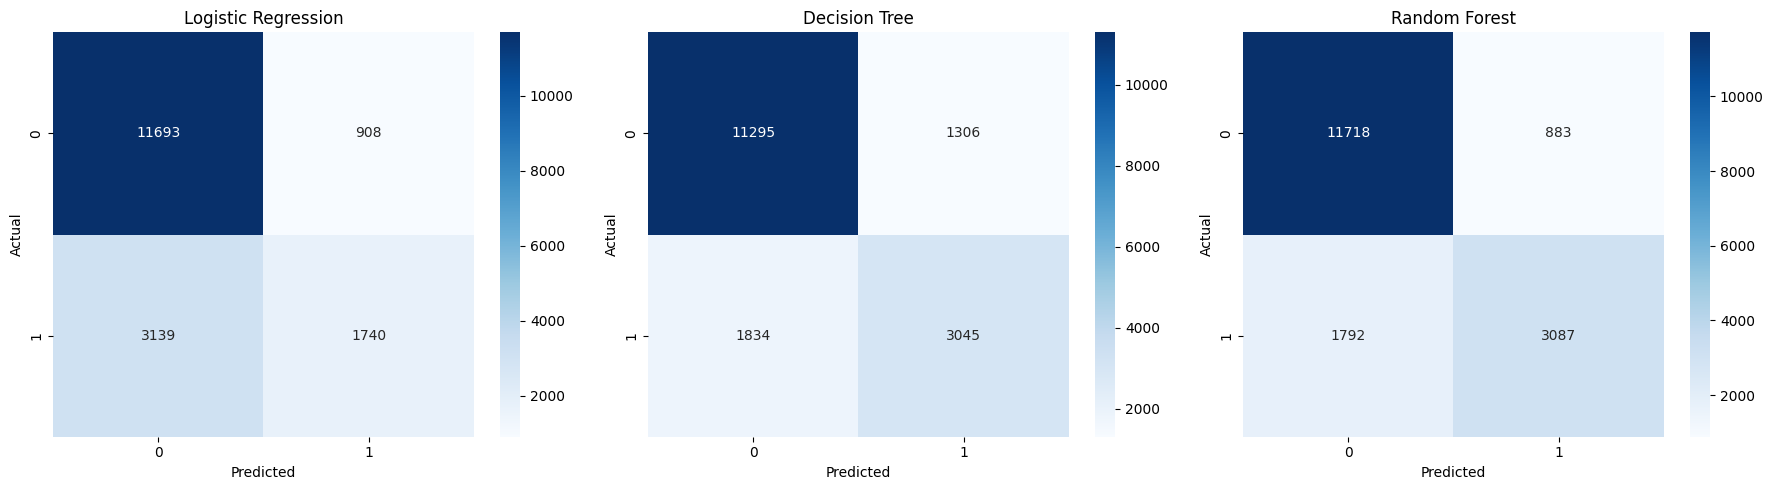

In [40]:
# Predict using all three trained models
y_pred_log = log_model.predict(X_test)
y_pred_tree = tree_model.predict(X_test)
y_pred_rf = rf_model.predict(X_test)

# Dictionary of predictions for each model
models = {
    "Logistic Regression": y_pred_log,
    "Decision Tree": y_pred_tree,
    "Random Forest": y_pred_rf
}

# Plot side-by-side confusion matrices
fig, axes = plt.subplots(1, 3, figsize=(18, 5))
for ax, (model_name, y_pred) in zip(axes, models.items()):
    cm = confusion_matrix(y_test, y_pred)
    sns.heatmap(cm, annot=True, fmt="d", cmap="Blues", ax=ax)
    ax.set_title(model_name)
    ax.set_xlabel("Predicted")
    ax.set_ylabel("Actual")

plt.tight_layout()
plt.show()

# ✅ Phase 13 – Comparison Bar Chart (Precision, Recall, F1-score by Class and Model)


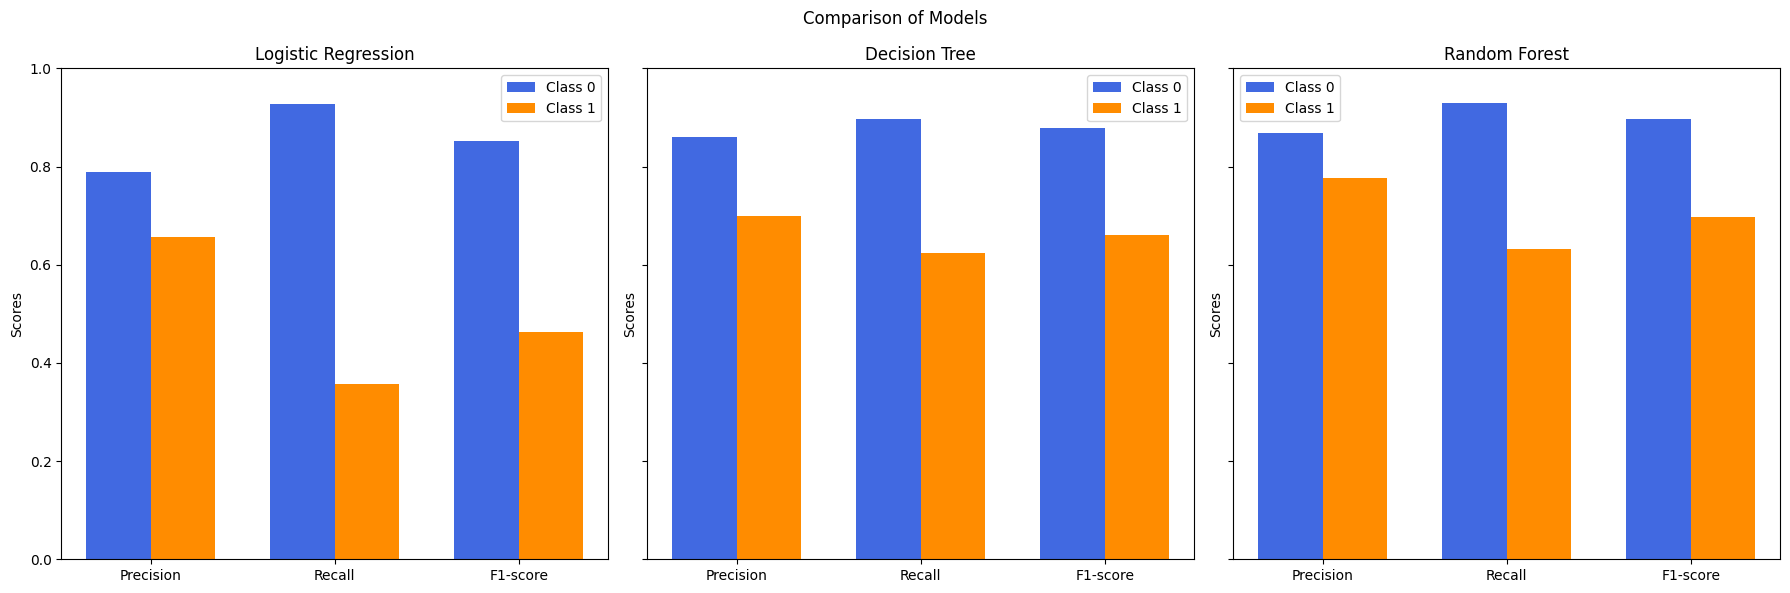

In [41]:
# Generate classification reports for each model
metrics_log = classification_report(y_test, y_pred_log, output_dict=True)
metrics_tree = classification_report(y_test, y_pred_tree, output_dict=True)
metrics_rf = classification_report(y_test, y_pred_rf, output_dict=True)

# Collect class-wise scores for all models
scores = {
    "Logistic Regression": {
        "Class 0": [metrics_log["0.0"]["precision"], metrics_log["0.0"]["recall"], metrics_log["0.0"]["f1-score"]],
        "Class 1": [metrics_log["1.0"]["precision"], metrics_log["1.0"]["recall"], metrics_log["1.0"]["f1-score"]],
    },
    "Decision Tree": {
        "Class 0": [metrics_tree["0.0"]["precision"], metrics_tree["0.0"]["recall"], metrics_tree["0.0"]["f1-score"]],
        "Class 1": [metrics_tree["1.0"]["precision"], metrics_tree["1.0"]["recall"], metrics_tree["1.0"]["f1-score"]],
    },
    "Random Forest": {
        "Class 0": [metrics_rf["0.0"]["precision"], metrics_rf["0.0"]["recall"], metrics_rf["0.0"]["f1-score"]],
        "Class 1": [metrics_rf["1.0"]["precision"], metrics_rf["1.0"]["recall"], metrics_rf["1.0"]["f1-score"]],
    }
}

# Plotting grouped bar charts
fig, axes = plt.subplots(1, 3, figsize=(18, 6), sharey=True)
x_labels = ["Precision", "Recall", "F1-score"]
bar_width = 0.35

for ax, (model_name, class_scores) in zip(axes, scores.items()):
    x = np.arange(len(x_labels))
    class0 = class_scores["Class 0"]
    class1 = class_scores["Class 1"]
    
    ax.bar(x - bar_width/2, class0, width=bar_width, label="Class 0", color="royalblue")
    ax.bar(x + bar_width/2, class1, width=bar_width, label="Class 1", color="darkorange")
    
    ax.set_title(model_name)
    ax.set_xticks(x)
    ax.set_xticklabels(x_labels)
    ax.set_ylim(0, 1)
    ax.set_ylabel("Scores")
    ax.legend()

plt.suptitle("Comparison of Models")
plt.tight_layout()
plt.show()

In [47]:
# Process in Python
for r in result:
    cancel_rate = builtins.round((r["canceled"] / r["total"]) * 100, 2)
    guest_type = "Repeated Guests" if r["_id"] == 1 else "New Guests"
    print(f"👤 {guest_type} → Total: {r['total']} | Canceled: {int(r['canceled'])} | Cancel Rate: {cancel_rate}%")


👤 Repeated Guests → Total: 3415 | Canceled: 261 | Cancel Rate: 7.64%
👤 New Guests → Total: 83981 | Canceled: 23764 | Cancel Rate: 28.3%


# ✅ 14. 🧳 Top 10 Cities by Number of Bookings



In [50]:
pipeline = [
    {"$group": {
        "_id": "$city",
        "bookings": {"$sum": 1}
    }},
    {"$sort": {"bookings": -1}},
    {"$limit": 10}
]

result = list(collection.aggregate(pipeline))

print("🏙️ Top 10 Cities by Bookings:")
for r in result:
    city = r["_id"]
    bookings = r["bookings"]
    print(f"{city}: {bookings} bookings")


🏙️ Top 10 Cities by Bookings:
Lisbon: 27453 bookings
London: 10433 bookings
Paris: 8837 bookings
Madrid: 7252 bookings
Berlin: 5387 bookings
Rome: 3066 bookings
Dublin: 3016 bookings
Brussels: 2081 bookings
Brasilia: 1995 bookings
Amsterdam: 1911 bookings


# ✅ 15. 🚗 Number of Bookings That Requested Parking


In [51]:
query = {"required_car_parking_spaces": {"$gt": 0}}
count = collection.count_documents(query)
print(f"🚗 Bookings with requested parking: {count}")


🚗 Bookings with requested parking: 7313


# ✅ 16. 👨‍👩‍👧‍👦 Percentage of Bookings by Families (with children or babies)


In [52]:
pipeline = [
    {"$group": {
        "_id": None,
        "total": {"$sum": 1},
        "families": {
            "$sum": {
                "$cond": [{"$or": [{"$gt": ["$children", 0]}, {"$gt": ["$babies", 0]}]}, 1, 0]
            }
        }
    }}
]

result = list(collection.aggregate(pipeline))[0]
rate = builtins.round(result["families"] / result["total"] * 100, 2)
print(f"👨‍👩‍👧‍👦 Family bookings: {result['families']} out of {result['total']} ({rate}%)")


👨‍👩‍👧‍👦 Family bookings: 9103 out of 87396 (10.42%)


# ✅ 17. 📅 Average Stay Duration by Customer Type


In [53]:
pipeline = [
    {"$project": {
        "customer_type": 1,
        "total_stay": {
            "$add": ["$stays_in_week_nights", "$stays_in_weekend_nights"]
        }
    }},
    {"$group": {
        "_id": "$customer_type",
        "avg_stay": {"$avg": "$total_stay"}
    }},
    {"$sort": {"avg_stay": -1}}
]

result = list(collection.aggregate(pipeline))

print("🛏️ Avg Stay Duration by Customer Type:")
for r in result:
    cust = r["_id"]
    avg = builtins.round(r["avg_stay"], 2)
    print(f"Customer Type {cust}: {avg} nights")


🛏️ Avg Stay Duration by Customer Type:
Customer Type Contract: 6.03 nights
Customer Type Transient: 3.58 nights
Customer Type Transient-Party: 3.34 nights
Customer Type Group: 2.92 nights
